# Étape 2 : Data Understanding (Exploration des Données)

Ce notebook est dédié à l'exploration et à la compréhension du dataset F1 avant de passer à la phase de modélisation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration des graphiques
%matplotlib inline
sns.set_theme(style="whitegrid")

## Section 1 — Dataset Overview

Chargement des données et premier aperçu de la structure.

In [2]:
df = pd.read_csv('f1_modeling_ready.csv')

print(f"Dimensions du dataset : {df.shape}")
print("\nTypes de données :")
print(df.dtypes)
df.head()

Dimensions du dataset : (26499, 19)

Types de données :
year                          int64
round                         int64
grid                          int64
qualifying_position         float64
driver_standing_pos         float64
driver_points_cum           float64
driver_wins_cum             float64
constructor_standing_pos    float64
constructor_points_cum      float64
constructor_wins_cum        float64
country                      object
positionOrder                 int64
points                      float64
laps                          int64
rank                        float64
statusId                      int64
podium                        int64
position_class                int64
finish_pos_penalty            int64
dtype: object


,year,round,grid,qualifying_position,driver_standing_pos,driver_points_cum,driver_wins_cum,constructor_standing_pos,constructor_points_cum,constructor_wins_cum,country,positionOrder,points,laps,rank,statusId,podium,position_class,finish_pos_penalty
0,2008,1,1,1.0,1.0,10.0,1.0,1.0,14.0,1.0,Australia,1,10.0,58,2.0,1,1,0,1
1,2008,1,5,5.0,2.0,8.0,0.0,3.0,8.0,0.0,Australia,2,8.0,58,3.0,1,1,1,2
2,2008,1,7,7.0,3.0,6.0,0.0,2.0,9.0,0.0,Australia,3,6.0,58,5.0,1,1,1,3
3,2008,1,11,12.0,4.0,5.0,0.0,4.0,5.0,0.0,Australia,4,5.0,58,7.0,1,0,2,4
4,2008,1,3,3.0,5.0,4.0,0.0,1.0,14.0,1.0,Australia,5,4.0,58,1.0,1,0,2,5


In [3]:
# Table des valeurs manquantes
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_table = pd.concat([missing_values, missing_percent], axis=1, keys=['Missing Count', 'Percentage'])
print("Valeurs manquantes par colonne :")
print(missing_table[missing_table['Missing Count'] > 0])

print("\nStatistiques descriptives de base :")
df.describe()

Valeurs manquantes par colonne :
                          Missing Count  Percentage
qualifying_position               16265   61.379675
driver_standing_pos                 469    1.769878
driver_points_cum                   469    1.769878
driver_wins_cum                     469    1.769878
constructor_standing_pos           1867    7.045549
constructor_points_cum             1867    7.045549
constructor_wins_cum               1867    7.045549
rank                              18249   68.866750

Statistiques descriptives de base :


,year,round,grid,qualifying_position,driver_standing_pos,driver_points_cum,driver_wins_cum,constructor_standing_pos,constructor_points_cum,constructor_wins_cum,positionOrder,points,laps,rank,statusId,podium,position_class,finish_pos_penalty
count,26499.000000,26499.000000,26499.000000,10234.000000,26030.000000,26030.000000,26030.000000,24632.000000,24632.000000,24632.000000,26499.000000,26499.000000,26499.000000,8250.000000,26499.000000,26499.000000,26499.000000,26499.000000
mean,1991.074456,8.418091,11.147062,11.213504,14.561544,18.336421,0.354091,6.461026,39.138580,0.788487,12.816559,1.957208,46.226914,10.350545,17.325559,0.126722,2.408883,11.995585
std,19.786110,4.992994,7.214294,6.271415,10.912575,41.848072,1.159515,3.980253,82.685999,1.950881,7.678869,4.302677,29.587220,6.150576,26.088787,0.332667,0.814539,6.338778
min,1950.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
25%,1977.000000,4.000000,5.000000,6.000000,7.000000,0.000000,0.000000,3.000000,1.000000,0.000000,6.000000,0.000000,23.000000,5.000000,1.000000,0.000000,2.000000,6.000000
50%,1991.000000,8.000000,11.000000,11.000000,13.000000,3.000000,0.000000,6.000000,10.000000,0.000000,12.000000,0.000000,53.000000,10.000000,10.000000,0.000000,3.000000,12.000000
75%,2008.000000,12.000000,17.000000,16.000000,20.000000,16.000000,0.000000,9.000000,36.000000,1.000000,18.000000,2.000000,66.000000,15.000000,14.000000,0.000000,3.000000,18.000000
max,2024.000000,22.000000,34.000000,28.000000,105.000000,575.000000,19.000000,21.000000,860.000000,21.000000,39.000000,50.000000,200.000000,24.000000,141.000000,1.000000,3.000000,20.000000


## Section 2 — Target Variable Analysis

Analyse des trois variables cibles (OBJ1, OBJ2, OBJ3/5).

Répartition Podium :
podium
0    87.327824
1    12.672176
Name: proportion, dtype: float64


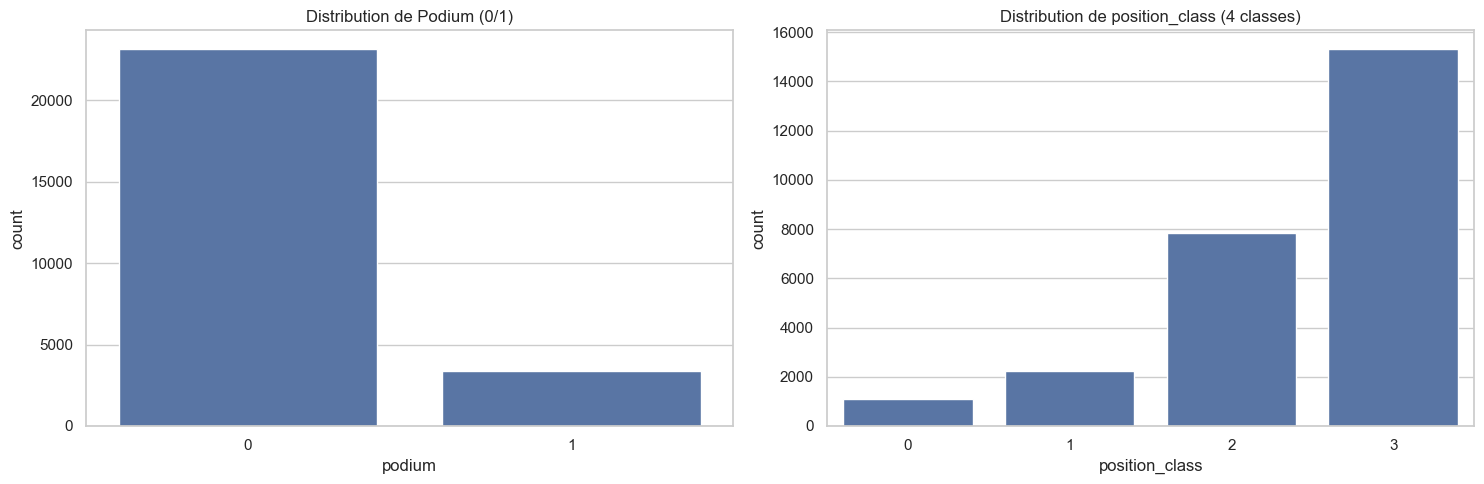

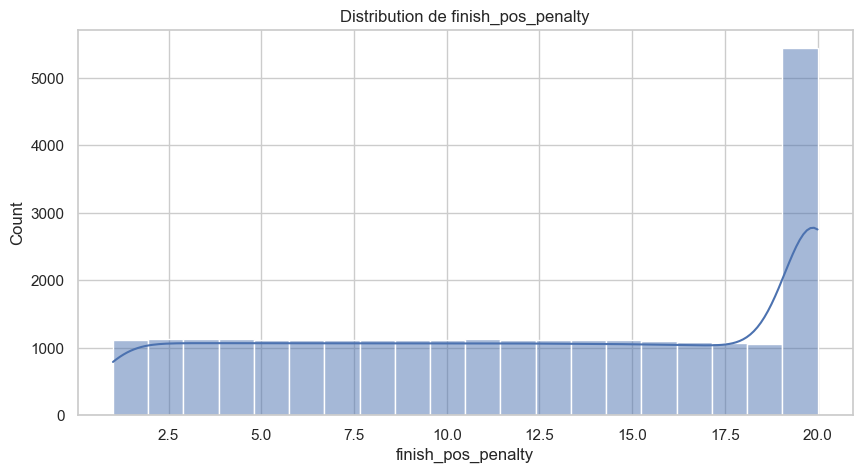

Statistiques finish_pos_penalty :
Min: 1, Max: 20, Mean: 12.00


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# OBJ1: podium
sns.countplot(data=df, x='podium', ax=axes[0])
axes[0].set_title('Distribution de Podium (0/1)')
podium_counts = df['podium'].value_counts(normalize=True) * 100
print(f"Répartition Podium :\n{podium_counts}")

# OBJ2: position_class
sns.countplot(data=df, x='position_class', ax=axes[1], order=[0, 1, 2, 3])
axes[1].set_title('Distribution de position_class (4 classes)')

plt.tight_layout()
plt.show()

# OBJ3/5: finish_pos_penalty
plt.figure(figsize=(10, 5))
sns.histplot(df['finish_pos_penalty'], bins=20, kde=True)
plt.title('Distribution de finish_pos_penalty')
plt.show()

print(f"Statistiques finish_pos_penalty :")
print(f"Min: {df['finish_pos_penalty'].min()}, Max: {df['finish_pos_penalty'].max()}, Mean: {df['finish_pos_penalty'].mean():.2f}")

## Section 3 — Feature Distributions

Examen de la distribution des variables prédictives et de leur relation avec les cibles.

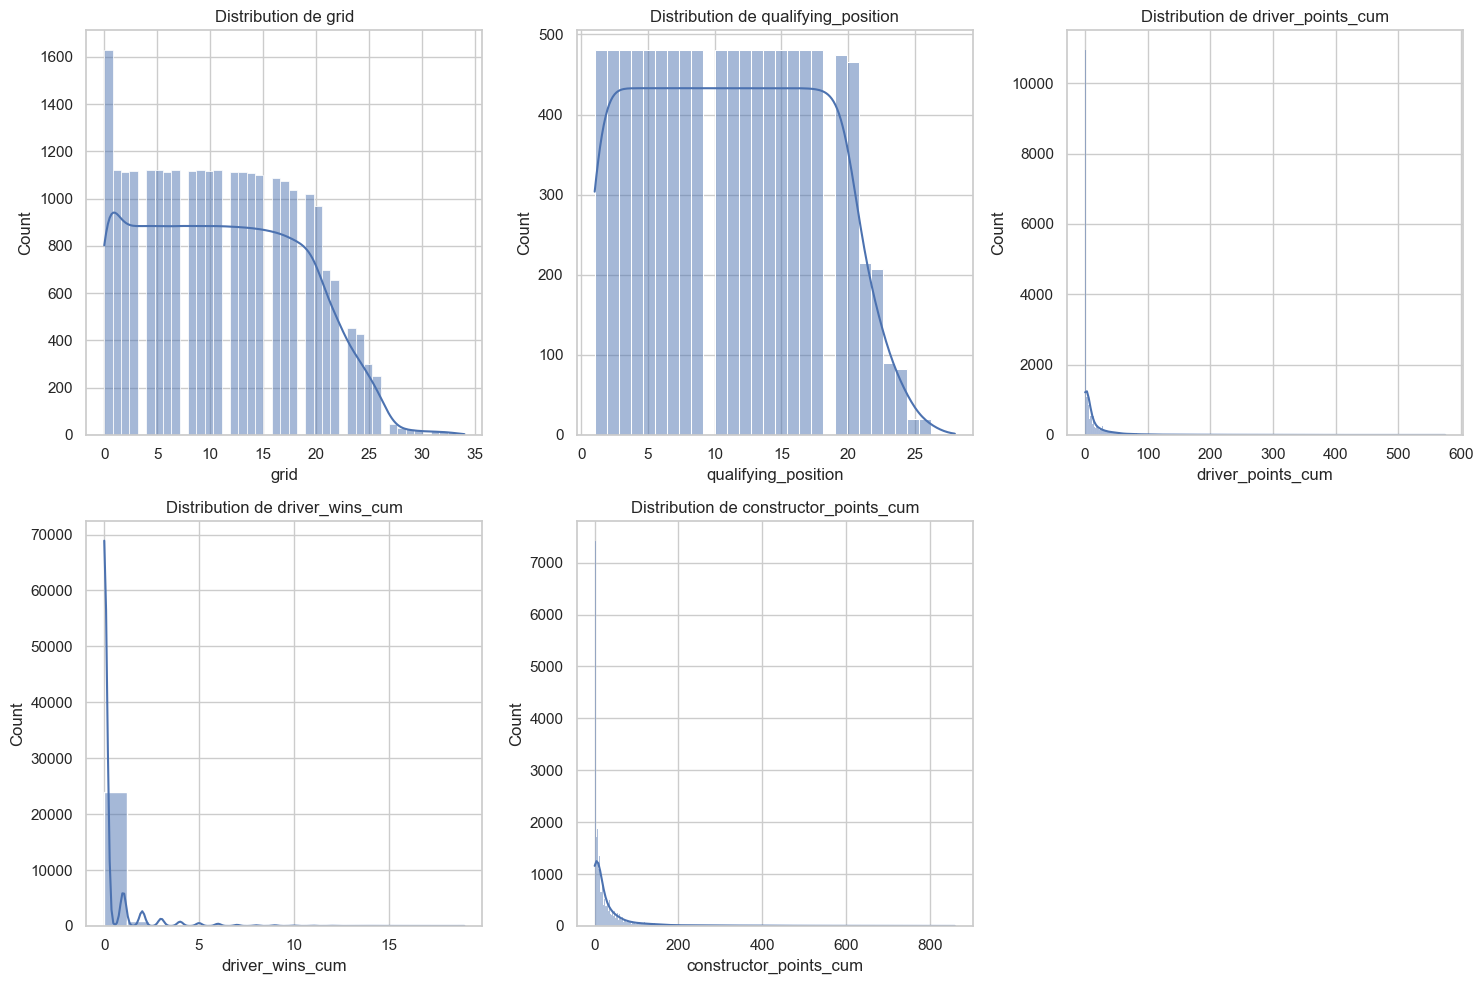

In [5]:
# Histogrammes des variables clés
features_to_plot = ['grid', 'qualifying_position', 'driver_points_cum', 
                    'driver_wins_cum', 'constructor_points_cum']

plt.figure(figsize=(15, 10))
for i, col in enumerate(features_to_plot, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution de {col}')

plt.tight_layout()
plt.show()

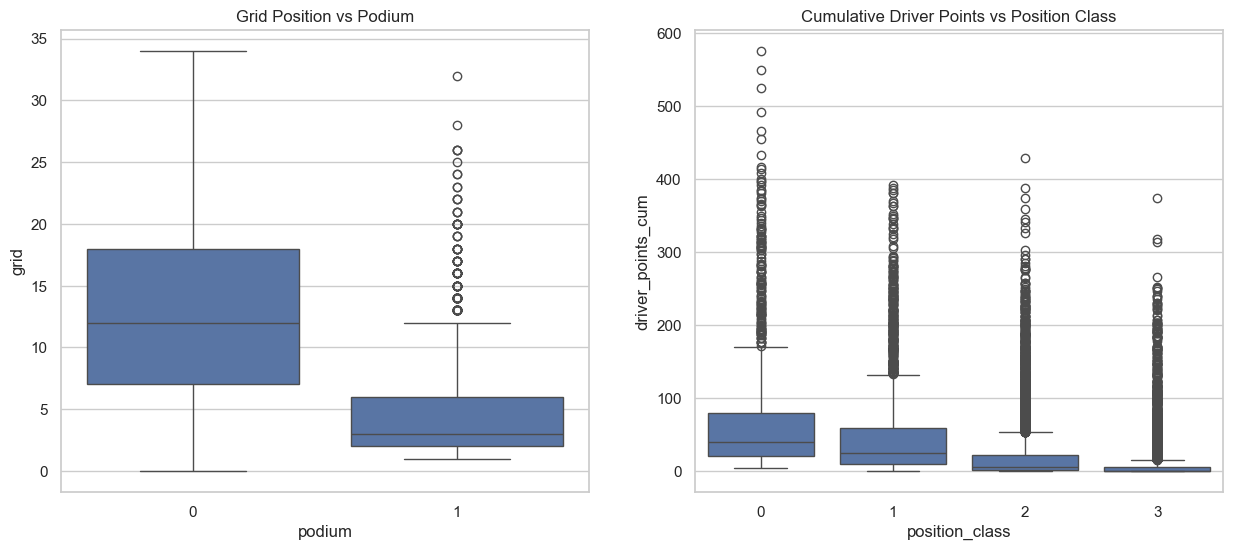

In [6]:
# Boxplots pour analyser les relations
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(data=df, x='podium', y='grid', ax=axes[0])
axes[0].set_title('Grid Position vs Podium')

sns.boxplot(data=df, x='position_class', y='driver_points_cum', ax=axes[1])
axes[1].set_title('Cumulative Driver Points vs Position Class')

plt.show()

## Section 4 — Correlations

Analyse des relations linéaires entre les variables.

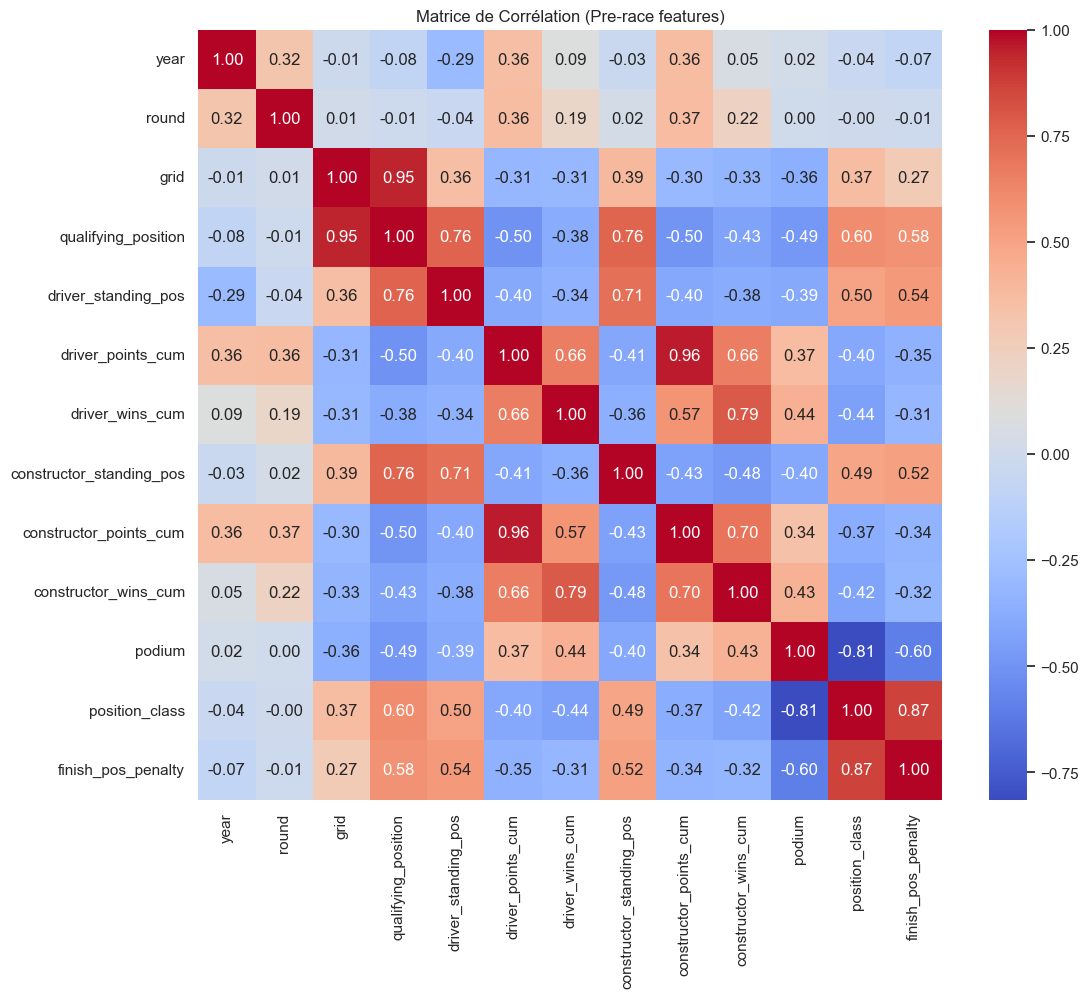


Top 5 des features corrélées avec 'podium' :
podium                  1.000000
position_class          0.814190
finish_pos_penalty      0.600578
qualifying_position     0.486806
driver_wins_cum         0.437575
constructor_wins_cum    0.429305
Name: podium, dtype: float64


In [7]:
# Exclusion des colonnes de leakage pour la corrélation
leakage_cols = ['positionOrder', 'points', 'laps', 'rank', 'statusId']
numeric_df = df.drop(columns=leakage_cols).select_dtypes(include=[np.number])

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice de Corrélation (Pre-race features)')
plt.show()

print("\nTop 5 des features corrélées avec 'podium' :")
print(numeric_df.corr()['podium'].abs().sort_values(ascending=False).head(6))

## Section 5 — Temporal Analysis

Évolution historique et influence de la grille.

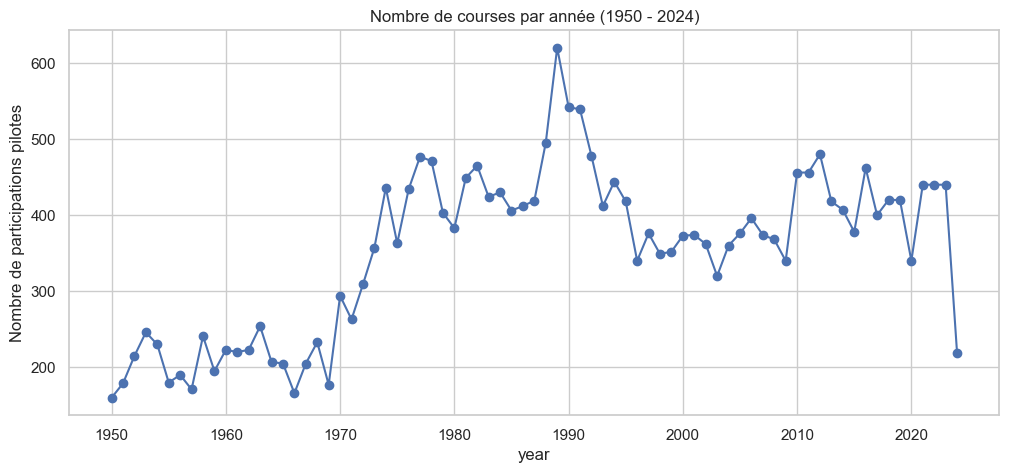

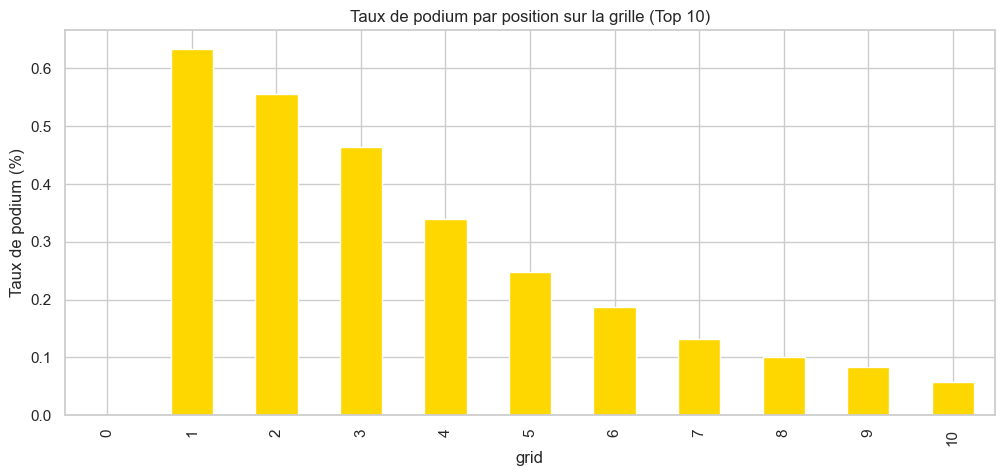

In [8]:
plt.figure(figsize=(12, 5))
df.groupby('year').size().plot(kind='line', marker='o')
plt.title('Nombre de courses par année (1950 - 2024)')
plt.ylabel('Nombre de participations pilotes')
plt.show()

plt.figure(figsize=(12, 5))
podium_rate_grid = df[df['grid'] <= 10].groupby('grid')['podium'].mean()
podium_rate_grid.plot(kind='bar', color='gold')
plt.title('Taux de podium par position sur la grille (Top 10)')
plt.ylabel('Taux de podium (%)')
plt.show()

## Section 6 — Key Findings

**Synthèse des observations pour la modélisation :**

1. **Déséquilibre des classes (OBJ1)** : Les podiums ne représentent qu'environ 15% des données. Un traitement spécifique (SMOTE, poids de classe) sera nécessaire pour la classification binaire.
2. **Importance de la grille** : La position sur la grille (`grid`) est fortement corrélée avec le résultat final. Partir dans le top 3 augmente drastiquement les chances de podium.
3. **Points cumulés** : `driver_points_cum` et `constructor_points_cum` montrent des distributions asymétriques (beaucoup de zéros), reflétant la domination de certaines écuries/pilotes.
4. **Corrélation des cibles** : `finish_pos_penalty` est inversement corrélée au podium, ce qui est cohérent (plus la pénalité est faible, plus le rang est élevé).
5. **Stabilité temporelle** : Le nombre de courses a augmenté significativement au fil des décennies, il faudra peut-être pondérer l'importance des données récentes.